**Daniel Suarez**

# Librerías 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report


np.random.seed(42)

# Perceptrón Original de Rosenblatt

In [2]:
class Rosenblatt:
    """
    Perceptrón Original de Rosenblatt desde cero.
    Usando la función de activación escalonada
    """
    def __init__(self, n_inputs, lr=0.5):
        """
        Args:
            n_inputs: número de entradas. Ej: 3, 6, 10, etc
            lr: learning rate
        """
        self.w = np.random.randn(n_inputs) * 0.01
        self.b = 0.0
        self.lr = lr

    def hardlim(self, z):
        return 1 if z >= 0 else 0
    
    def forward(self, X):
        self.X = X
        self.z = np.dot(self.w, X) + self.b
        self.a = self.hardlim(self.z)

        return self.a

    def backward(self, y_real):
        error = y_real - self.a

        self.w += self.lr * error * self.X
        self.b += self.lr * error

        return error

    def train(self, X, y, epochs=5000):
        for ep in range(epochs):
            total_error = 0
            for i in range(len(X)):
                output = self.forward(X[i])
                error = self.backward(y[i])
                total_error += abs(error)
            print(f"Epoch: {ep} \tError: {total_error[0]} \tWeight: {self.w} \tBias: {self.b[0]}")
            
            if total_error == 0:
                print(f"Convergió en la época: {ep}")
                break

    def show_preds(self, X):
        for i in range(len(X)):
            pred = self.forward(X[i])
            print(f"AND({X[i] [0]}, {X[i] [1]}) = {pred:.4f} -> Clase: {round(pred)}")
    
    def plot_decision_boundary(self, X):
        plt.scatter(X[:, 0], X[:, 1])

        x1 = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100)
        x2 = -(self.w[0] * x1 + self.b) / self.w[1]
        plt.plot(x1, x2)


        plt.title("Frontera de decisión final")
        plt.tight_layout()
        plt.grid()
        plt.show()

## Compuerta AND: problema linealmente separable ideal para validar un perceptrón simple.


In [3]:
X = np.array(
    [
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
    ]
)
y = np.array(
    [
        0,
        0,
        0,
        1
    ]
)

y = y.reshape(-1, 1)

- `n_inputs=2` porque AND tiene 2 variables de entrada.
- `lr=0.01`: tasa pequeña para actualizaciones estables y evitar oscilaciones.
- `n_epochs=1000`: tope suficiente para que converja en un problema pequeño.

In [4]:
perceptron = Rosenblatt(n_inputs=2, lr=0.01)
perceptron.train(X, y, epochs=1000)

Epoch: 0 	Error: 2 	Weight: [0.01496714 0.00861736] 	Bias: 0.0
Epoch: 1 	Error: 3 	Weight: [0.01496714 0.01861736] 	Bias: -0.01
Epoch: 2 	Error: 1 	Weight: [0.01496714 0.00861736] 	Bias: -0.02
Epoch: 3 	Error: 0 	Weight: [0.01496714 0.00861736] 	Bias: -0.02
Convergió en la época: 3


In [5]:
perceptron.show_preds(X)

AND(0, 0) = 0.0000 -> Clase: 0
AND(0, 1) = 0.0000 -> Clase: 0
AND(1, 0) = 0.0000 -> Clase: 0
AND(1, 1) = 1.0000 -> Clase: 1


## Ecuación de la frontera de decisión

$w_1x_1 + w_2x_2 + b = 0$


In [6]:
print(f"{perceptron.w[0]:.6f}X1 + {perceptron.w[1]:.6f}X2 {perceptron.b[0]} = 0")

0.014967X1 + 0.008617X2 -0.02 = 0


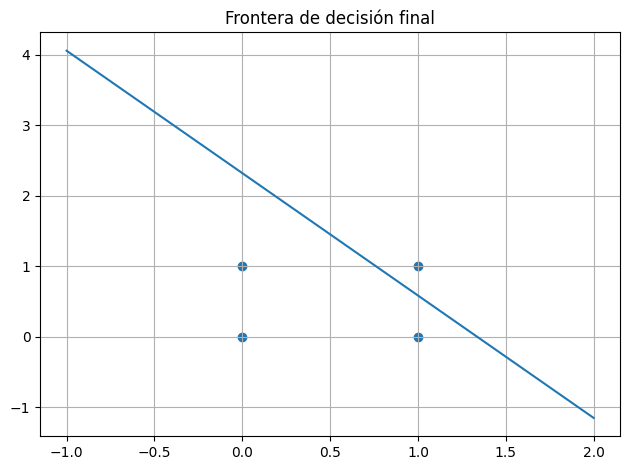

In [7]:
perceptron.plot_decision_boundary(X)

# Red Neuronal Multicapa

In [ ]:
class MLP:
    """
    Red Neuronal Multicapa desde cero.
    Capas ocultas usan ReLU, capa de salida usa Softmax.
    Incluye Early Stopping para detener el entrenamiento cuando converge.
    """

    def __init__(self, layer_sizes, lr=0.01):
        """
        Args:
            layer_sizes: lista con neuronas por capa. Ej: [2, 32, 16, 1]
            lr: learning rate
        """
        self.lr = lr
        self.losses = []
        self.accuracies = []
        self.stopped_epoch = None

        self.weights = []
        self.biases = []
        for i in range(len(layer_sizes) - 1):
            scale = np.sqrt(2.0 / layer_sizes[i])
            W = np.random.randn(layer_sizes[i], layer_sizes[i + 1]) * scale
            b = np.zeros((1, layer_sizes[i + 1]))
            self.weights.append(W)
            self.biases.append(b)

        print(f"Red creada: {' → '.join(map(str, layer_sizes))}")
        total_params = sum(w.size + b.size for w, b in zip(self.weights, self.biases))
        print(f"Total de parámetros entrenables: {total_params}")

    def relu(self, z):
        return np.maximum(0, z)

    def relu_derivative(self, z):
        return (z > 0).astype(float)

    def softmax(self, z):
        e_z = np.exp(z - np.max(z, axis=-1, keepdims=True))

        return e_z / np.sum(e_z, axis=-1, keepdims=True)

    def forward(self, X):
        """Pasa los datos por cada capa de la red."""
        self.activations = [X]
        self.z_values = []

        current = X
        for i in range(len(self.weights)):
            z = current @ self.weights[i] + self.biases[i]
            self.z_values.append(z)

            if i == len(self.weights) - 1:
                # Última capa → Softmax (Multiclase)
                current = self.softmax(z)
            else:
                # Capas ocultas → ReLU (no linealidad)
                current = self.relu(z)

            self.activations.append(current)

        return current

    def backward(self, X, y):
        """Calcula gradientes y actualiza pesos (hacia atrás)."""
        m = len(y)
        output = self.activations[-1]

        delta = output - y

        for i in reversed(range(len(self.weights))):
            dW = self.activations[i].T @ delta / m
            db = np.sum(delta, axis=0, keepdims=True) / m

            if i > 0:
                delta = (delta @ self.weights[i].T) * self.relu_derivative(self.z_values[i - 1])

            self.weights[i] -= self.lr * dW
            self.biases[i] -= self.lr * db

    def train(self, X, y, max_epochs=10000, patience=200, min_delta=1e-5, print_every=500):
        """
        Entrena la red.

        Args:
            max_epochs: máximo de épocas permitidas
            patience: épocas consecutivas sin mejora antes de parar
            min_delta: mejora mínima en el loss para considerar progreso
            print_every: cada cuántas épocas imprimir progreso
        """
        best_loss = np.inf
        epochs_no_improve = 0
        best_weights = None

        for epoch in range(max_epochs):
            pred = self.forward(X)

            # Calcular Loss (Categorical Cross-Entropy)
            eps = 1e-8
            loss = loss = -np.mean(np.sum(y * np.log(np.clip(pred, eps, 1.0)), axis=1))
            self.losses.append(loss)

            # Accuracy
            y_true = np.argmax(y, axis=1)
            y_pred = np.argmax(pred, axis=1)
            acc = np.mean(y_pred == y_true) * 100
            self.accuracies.append(acc)

            self.backward(X, y)

            if loss < best_loss - min_delta:
                best_loss = loss
                epochs_no_improve = 0
                best_weights = [(w.copy(), b.copy()) for w, b in zip(self.weights, self.biases)]
            else:
                epochs_no_improve += 1

            if epochs_no_improve >= patience:
                self.stopped_epoch = epoch
                if best_weights:
                    for i, (w, b) in enumerate(best_weights):
                        self.weights[i] = w
                        self.biases[i] = b
                pred = self.forward(X)
                acc = np.mean((pred.flatten() > 0.5) == y) * 100
                print(f"Early Stopping en época {epoch} (sin mejora por {patience} épocas)")
                print(f"Mejor Loss: {best_loss:.6f} \t Accuracy: {acc:.1f}%")
                return

            if epoch % print_every == 0:
                print(f"Epoch {epoch:5d} | Loss: {loss:.4f} | Accuracy: {acc:.1f}%")

        self.stopped_epoch = max_epochs
        pred = self.forward(X)
        y_true = np.argmax(y, axis=1)
        y_pred = np.argmax(pred, axis=1)
        acc = np.mean(y_pred == y_true) * 100
        print(f"\nAlcanzó el máximo de {max_epochs} épocas")
        print(f"\tLoss: {self.losses[-1]:.4f} \t Accuracy: {acc:.1f}%")

    def predict(self, X):
        return np.argmax(self.forward(X), axis=1)

In [9]:
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

scaler = StandardScaler()
encoder = OneHotEncoder(sparse_output=False)

X_scaled = scaler.fit_transform(X_iris)
y_onehot = encoder.fit_transform(y_iris.reshape(-1, 1))
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_onehot, test_size=0.2, random_state=42)

Arquitectura [4,16,8,3]:
- 4 entradas (features de Iris)
- 2 capas ocultas (16 y 8) para captar no linealidad sin sobredimensionar
- 3 salidas (una por clase)
- `lr=0.05`: compromiso entre velocidad de aprendizaje y estabilidad.

- `max_epochs=5000`: margen amplio de entrenamiento.
- `patience=200`: Early Stopping para evitar sobreentrenamiento si no mejora.

In [10]:
mlp = MLP(layer_sizes=[4, 16, 8, 3], lr=0.05)
mlp.train(X_train, y_train, max_epochs=5000, patience=200, print_every=500)

Red creada: 4 → 16 → 8 → 3
Total de parámetros entrenables: 243
Epoch     0 | Loss: 1.8263 | Accuracy: 33.3%
Epoch   500 | Loss: 0.0671 | Accuracy: 97.5%
Epoch  1000 | Loss: 0.0443 | Accuracy: 98.3%
Epoch  1500 | Loss: 0.0392 | Accuracy: 98.3%
Epoch  2000 | Loss: 0.0364 | Accuracy: 98.3%
Epoch  2500 | Loss: 0.0342 | Accuracy: 98.3%
Epoch  3000 | Loss: 0.0316 | Accuracy: 98.3%
Epoch  3500 | Loss: 0.0291 | Accuracy: 98.3%
Epoch  4000 | Loss: 0.0264 | Accuracy: 98.3%
Epoch  4500 | Loss: 0.0234 | Accuracy: 98.3%

Alcanzó el máximo de 5000 épocas
	Loss: 0.0207 	 Accuracy: 98.3%


In [11]:
y_pred = mlp.predict(X_test)
y_test_decode = encoder.inverse_transform(y_test)

In [12]:
print(classification_report(y_test_decode, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

